In [25]:
# In this final step, we will analyze the data we have collected
# and visualize it using matplotlib.
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [26]:
# Finding the optimal config - find models that are best in multiple metrics
def find_best_optimal_models(df, percentile=99):
    """Find models that are optimal in at least one metric"""
    subset = df[df['percentile'] == percentile].copy()
    
    # Rank by each metric (lower rank = better)
    subset['mae_rank'] = subset['mae'].rank(ascending=True)
    subset['mse_rank'] = subset['mse'].rank(ascending=True)  # Lower MSE is better
    subset['r2_rank'] = subset['r2'].rank(ascending=False)  # Higher R² is better
    subset['worst_error_rank'] = subset['worst_avg_error'].rank(ascending=True)
    
    # Find average rank across all 4 metrics
    subset['avg_rank'] = (subset['mae_rank'] + subset['mse_rank'] + 
                         subset['r2_rank'] + subset['worst_error_rank']) / 4
    
    return subset.sort_values('avg_rank')

In [27]:
regression_baseline = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/1_regression/regression_baseline_results.csv', header=0)
regression_fe = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/1_regression/regression_fe_results.csv', header=0)

lasso_baseline = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/2_lasso/lasso_full_baseline_results.csv', header=0)
lasso_fe = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/2_lasso/lasso_full_fe_results.csv', header=0)


# Ranking the models based on their performance metrics in the 99th percentile
regression_baseline_ranked = find_best_optimal_models(regression_baseline)
regression_fe_ranked = find_best_optimal_models(regression_fe)

lasso_baseline_ranked = find_best_optimal_models(lasso_baseline)
lasso_fe_ranked = find_best_optimal_models(lasso_fe)

# Recreate the complete database for random forest models
load_rf_baseline_data = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/3_randomforest/random_forest_full_baseline_results.csv', header=0)
load_rf_fe_data = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/3_randomforest/random_forest_full_fe_results.csv', header=0)

# rank the random forest models
random_forest_baseline_ranked = find_best_optimal_models(load_rf_baseline_data)
random_forest_fe_ranked = find_best_optimal_models(load_rf_fe_data)

Regression

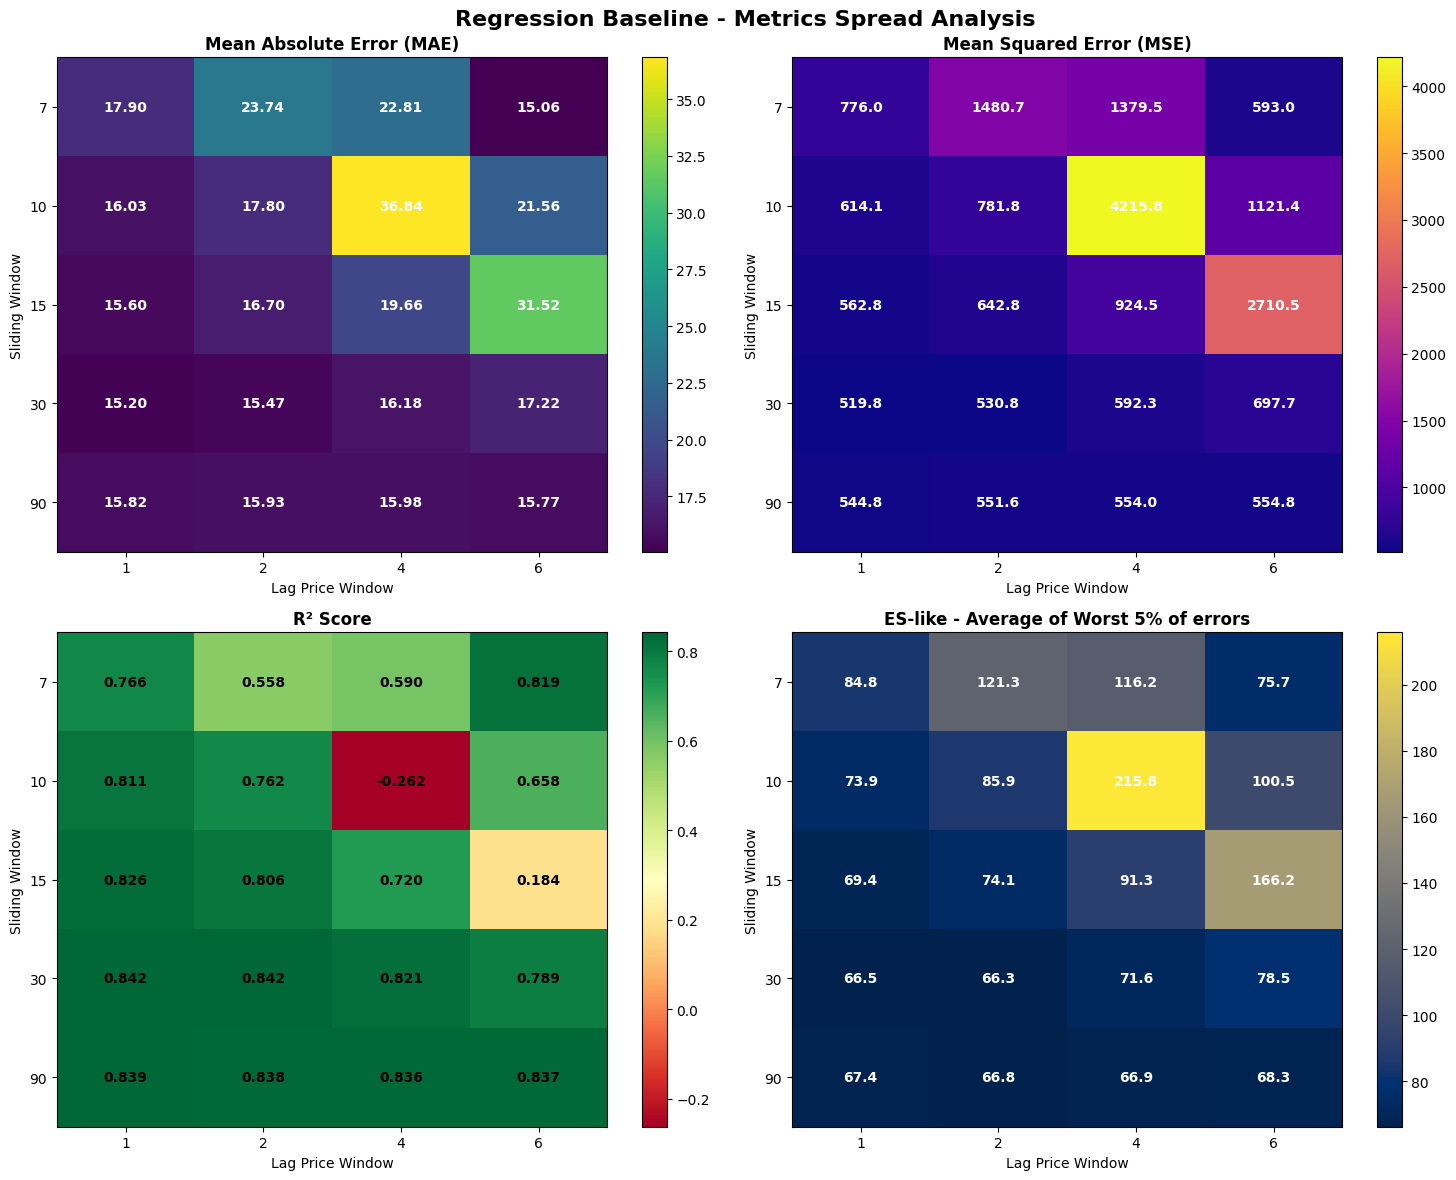

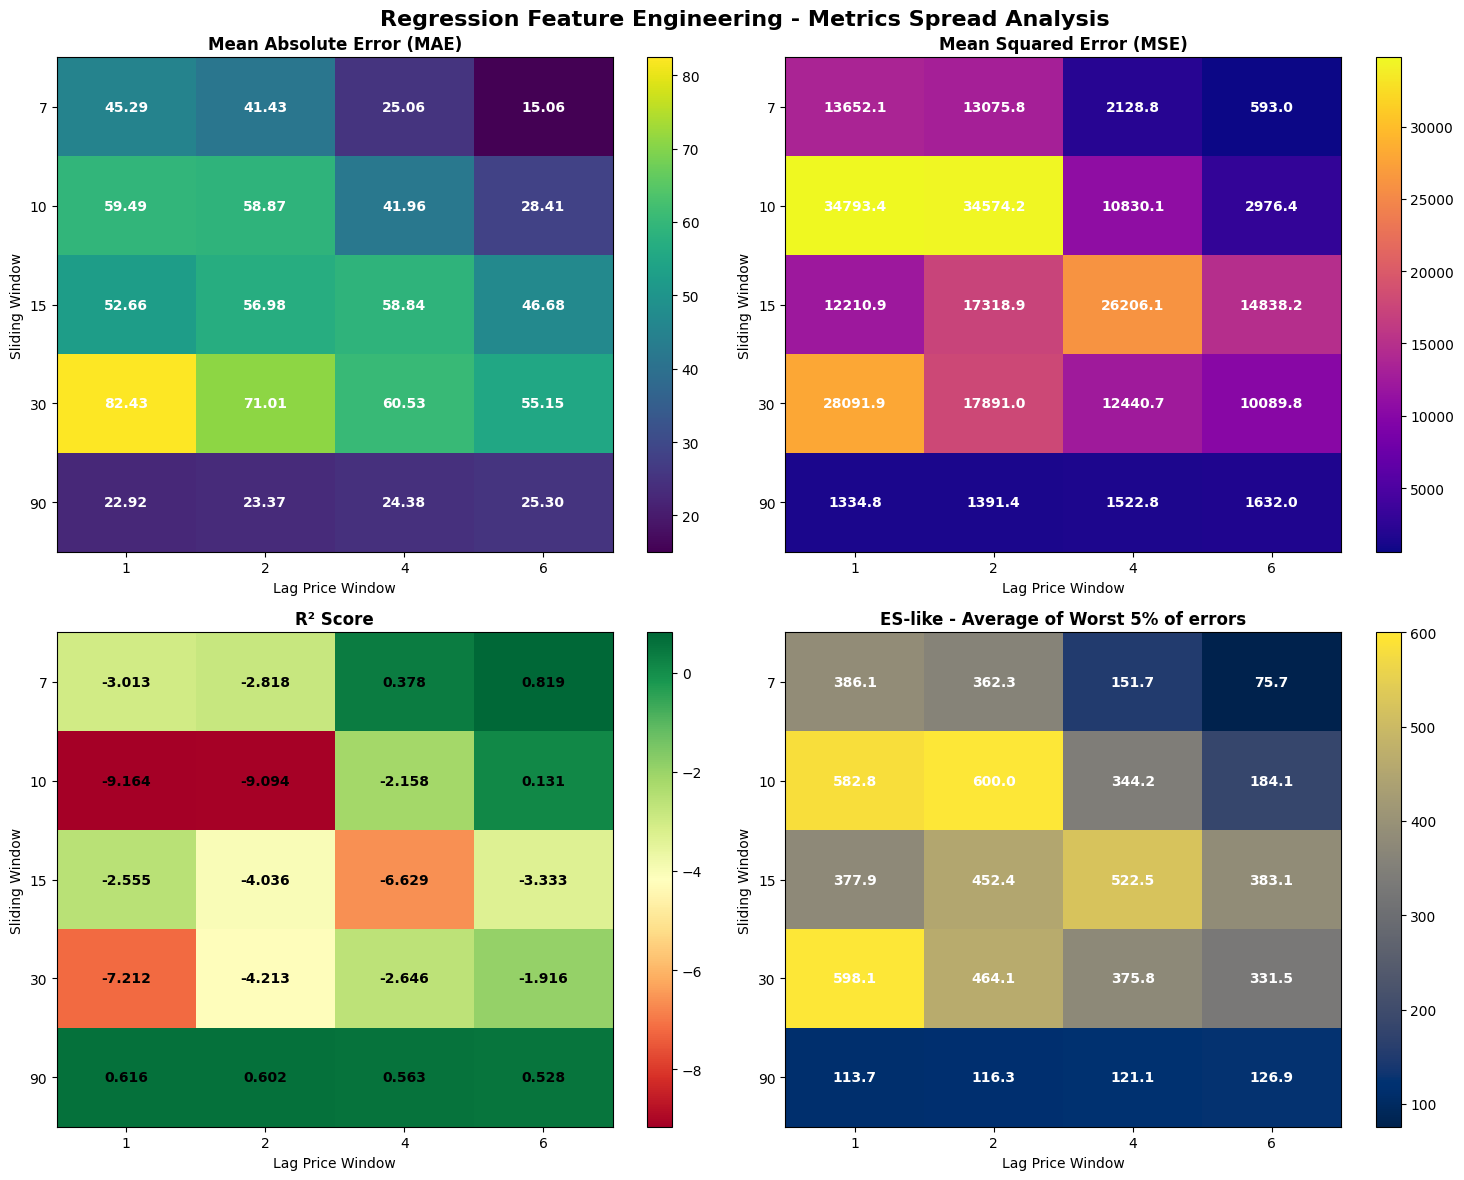

In [28]:
# Plot the spread between the best and worst metric values for each model
# Plot MAE, MSE, R², and worst error for each model

# Create a comprehensive visualization of all metrics across sliding_window and lag_price_window
def plot_metric_spreads(df, model_name, figsize=(15, 12)):
    """Plot heatmaps for each metric with sliding_window and lag_price_window as axes"""
    
    # Create pivot tables for each metric
    mae_pivot = df.pivot_table(values='mae', index='sliding_window', columns='lag_price_window', aggfunc='mean')
    mse_pivot = df.pivot_table(values='mse', index='sliding_window', columns='lag_price_window', aggfunc='mean')
    r2_pivot = df.pivot_table(values='r2', index='sliding_window', columns='lag_price_window', aggfunc='mean')
    worst_error_pivot = df.pivot_table(values='worst_avg_error', index='sliding_window', columns='lag_price_window', aggfunc='mean')
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(f'{model_name} - Metrics Spread Analysis', fontsize=16, fontweight='bold')
    
    # MAE heatmap
    im1 = axes[0, 0].imshow(mae_pivot.values, cmap='viridis', aspect='auto')
    axes[0, 0].set_title('Mean Absolute Error (MAE)', fontweight='bold')
    axes[0, 0].set_xlabel('Lag Price Window')
    axes[0, 0].set_ylabel('Sliding Window')
    axes[0, 0].set_xticks(range(len(mae_pivot.columns)))
    axes[0, 0].set_xticklabels(mae_pivot.columns)
    axes[0, 0].set_yticks(range(len(mae_pivot.index)))
    axes[0, 0].set_yticklabels(mae_pivot.index)
    plt.colorbar(im1, ax=axes[0, 0])
    
    # Add values to cells
    for i in range(len(mae_pivot.index)):
        for j in range(len(mae_pivot.columns)):
            if not np.isnan(mae_pivot.iloc[i, j]):
                axes[0, 0].text(j, i, f'{mae_pivot.iloc[i, j]:.2f}', 
                               ha='center', va='center', color='white', fontweight='bold')
    
    # MSE heatmap
    im2 = axes[0, 1].imshow(mse_pivot.values, cmap='plasma', aspect='auto')
    axes[0, 1].set_title('Mean Squared Error (MSE)', fontweight='bold')
    axes[0, 1].set_xlabel('Lag Price Window')
    axes[0, 1].set_ylabel('Sliding Window')
    axes[0, 1].set_xticks(range(len(mse_pivot.columns)))
    axes[0, 1].set_xticklabels(mse_pivot.columns)
    axes[0, 1].set_yticks(range(len(mse_pivot.index)))
    axes[0, 1].set_yticklabels(mse_pivot.index)
    plt.colorbar(im2, ax=axes[0, 1])
    
    # Add values to cells
    for i in range(len(mse_pivot.index)):
        for j in range(len(mse_pivot.columns)):
            if not np.isnan(mse_pivot.iloc[i, j]):
                axes[0, 1].text(j, i, f'{mse_pivot.iloc[i, j]:.1f}', 
                               ha='center', va='center', color='white', fontweight='bold')
    
    # R² heatmap
    im3 = axes[1, 0].imshow(r2_pivot.values, cmap='RdYlGn', aspect='auto')
    axes[1, 0].set_title('R² Score', fontweight='bold')
    axes[1, 0].set_xlabel('Lag Price Window')
    axes[1, 0].set_ylabel('Sliding Window')
    axes[1, 0].set_xticks(range(len(r2_pivot.columns)))
    axes[1, 0].set_xticklabels(r2_pivot.columns)
    axes[1, 0].set_yticks(range(len(r2_pivot.index)))
    axes[1, 0].set_yticklabels(r2_pivot.index)
    plt.colorbar(im3, ax=axes[1, 0])
    
    # Add values to cells
    for i in range(len(r2_pivot.index)):
        for j in range(len(r2_pivot.columns)):
            if not np.isnan(r2_pivot.iloc[i, j]):
                axes[1, 0].text(j, i, f'{r2_pivot.iloc[i, j]:.3f}', 
                               ha='center', va='center', color='black', fontweight='bold')
    
    # Worst Error heatmap
    im4 = axes[1, 1].imshow(worst_error_pivot.values, cmap='cividis', aspect='auto')
    axes[1, 1].set_title('ES-like - Average of Worst 5% of errors', fontweight='bold')
    axes[1, 1].set_xlabel('Lag Price Window')
    axes[1, 1].set_ylabel('Sliding Window')
    axes[1, 1].set_xticks(range(len(worst_error_pivot.columns)))
    axes[1, 1].set_xticklabels(worst_error_pivot.columns)
    axes[1, 1].set_yticks(range(len(worst_error_pivot.index)))
    axes[1, 1].set_yticklabels(worst_error_pivot.index)
    plt.colorbar(im4, ax=axes[1, 1])
    
    # Add values to cells
    for i in range(len(worst_error_pivot.index)):
        for j in range(len(worst_error_pivot.columns)):
            if not np.isnan(worst_error_pivot.iloc[i, j]):
                axes[1, 1].text(j, i, f'{worst_error_pivot.iloc[i, j]:.1f}', 
                               ha='center', va='center', color='white', fontweight='bold')
    
    plt.tight_layout()
    # save the figure
    plt.savefig(f'{model_name}_metrics_spread_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot for all models
plot_metric_spreads(regression_baseline_ranked, 'Regression Baseline')
plot_metric_spreads(regression_fe_ranked, 'Regression Feature Engineering')

Lasso

In [29]:
def plot_lasso_best_alpha_heatmaps(df, model_name, figsize=(20, 15)):
    """Plot heatmaps showing best alpha and corresponding metric values"""
    
    # Find best alpha for each sliding_window, lag_price_window combination
    best_configs = df.loc[df.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    # Create pivot tables for metrics with best alpha
    mae_pivot = best_configs.pivot_table(values='mae', index='sliding_window', columns='lag_price_window')
    mse_pivot = best_configs.pivot_table(values='mse', index='sliding_window', columns='lag_price_window')
    r2_pivot = best_configs.pivot_table(values='r2', index='sliding_window', columns='lag_price_window')
    worst_error_pivot = best_configs.pivot_table(values='worst_avg_error', index='sliding_window', columns='lag_price_window')
    alpha_pivot = best_configs.pivot_table(values='alpha', index='sliding_window', columns='lag_price_window')
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(f'{model_name} - Best Alpha Configurations', fontsize=16, fontweight='bold')
    
    # Flatten axes for easier indexing
    axes = axes.flatten()
    
    # MAE with best alpha
    im1 = axes[0].imshow(mae_pivot.values, cmap='viridis', aspect='auto')
    axes[0].set_title('MAE', fontweight='bold')
    axes[0].set_xlabel('Lag Price Window')
    axes[0].set_ylabel('Sliding Window')
    axes[0].set_xticks(range(len(mae_pivot.columns)))
    axes[0].set_xticklabels(mae_pivot.columns)
    axes[0].set_yticks(range(len(mae_pivot.index)))
    axes[0].set_yticklabels(mae_pivot.index)
    plt.colorbar(im1, ax=axes[0])
    
    # Add values to cells
    for i in range(len(mae_pivot.index)):
        for j in range(len(mae_pivot.columns)):
            if not np.isnan(mae_pivot.iloc[i, j]):
                mae_val = mae_pivot.iloc[i, j]
                alpha_val = alpha_pivot.iloc[i, j]
                axes[0].text(j, i, f'{mae_val:.2f}\n(α={alpha_val})', 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # MSE with best alpha
    im2 = axes[1].imshow(mse_pivot.values, cmap='plasma', aspect='auto')
    axes[1].set_title('MSE', fontweight='bold')
    axes[1].set_xlabel('Lag Price Window')
    axes[1].set_ylabel('Sliding Window')
    axes[1].set_xticks(range(len(mse_pivot.columns)))
    axes[1].set_xticklabels(mse_pivot.columns)
    axes[1].set_yticks(range(len(mse_pivot.index)))
    axes[1].set_yticklabels(mse_pivot.index)
    plt.colorbar(im2, ax=axes[1])
    
    for i in range(len(mse_pivot.index)):
        for j in range(len(mse_pivot.columns)):
            if not np.isnan(mse_pivot.iloc[i, j]):
                mse_val = mse_pivot.iloc[i, j]
                alpha_val = alpha_pivot.iloc[i, j]
                axes[1].text(j, i, f'{mse_val:.1f}\n(α={alpha_val})', 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # R² with best alpha
    im3 = axes[2].imshow(r2_pivot.values, cmap='RdYlGn', aspect='auto')
    axes[2].set_title('R²', fontweight='bold')
    axes[2].set_xlabel('Lag Price Window')
    axes[2].set_ylabel('Sliding Window')
    axes[2].set_xticks(range(len(r2_pivot.columns)))
    axes[2].set_xticklabels(r2_pivot.columns)
    axes[2].set_yticks(range(len(r2_pivot.index)))
    axes[2].set_yticklabels(r2_pivot.index)
    plt.colorbar(im3, ax=axes[2])
    
    for i in range(len(r2_pivot.index)):
        for j in range(len(r2_pivot.columns)):
            if not np.isnan(r2_pivot.iloc[i, j]):
                r2_val = r2_pivot.iloc[i, j]
                alpha_val = alpha_pivot.iloc[i, j]
                axes[2].text(j, i, f'{r2_val:.3f}\n(α={alpha_val})', 
                        ha='center', va='center', color='black', fontweight='bold', fontsize=9)
    
    # Worst Error with best alpha
    im4 = axes[3].imshow(worst_error_pivot.values, cmap='cividis', aspect='auto')
    axes[3].set_title('ES-like - Average of Worst 5% Errors', fontweight='bold')
    axes[3].set_xlabel('Lag Price Window')
    axes[3].set_ylabel('Sliding Window')
    axes[3].set_xticks(range(len(worst_error_pivot.columns)))
    axes[3].set_xticklabels(worst_error_pivot.columns)
    axes[3].set_yticks(range(len(worst_error_pivot.index)))
    axes[3].set_yticklabels(worst_error_pivot.index)
    plt.colorbar(im4, ax=axes[3])
    
    for i in range(len(worst_error_pivot.index)):
        for j in range(len(worst_error_pivot.columns)):
            if not np.isnan(worst_error_pivot.iloc[i, j]):
                error_val = worst_error_pivot.iloc[i, j]
                alpha_val = alpha_pivot.iloc[i, j]
                axes[3].text(j, i, f'{error_val:.1f}\n(α={alpha_val})', 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # Best Alpha values heatmap
    im5 = axes[4].imshow(alpha_pivot.values, cmap='viridis', aspect='auto')
    axes[4].set_title('Best Alpha Values', fontweight='bold')
    axes[4].set_xlabel('Lag Price Window')
    axes[4].set_ylabel('Sliding Window')
    axes[4].set_xticks(range(len(alpha_pivot.columns)))
    axes[4].set_xticklabels(alpha_pivot.columns)
    axes[4].set_yticks(range(len(alpha_pivot.index)))
    axes[4].set_yticklabels(alpha_pivot.index)
    plt.colorbar(im5, ax=axes[4])
    
    # Add alpha values as text
    for i in range(len(alpha_pivot.index)):
        for j in range(len(alpha_pivot.columns)):
            if not np.isnan(alpha_pivot.iloc[i, j]):
                axes[4].text(j, i, f'{alpha_pivot.iloc[i, j]}', 
                        ha='center', va='center', color='white', fontweight='bold')
    
    # Hide the last subplot (6th position) since we only have 5 plots
    axes[5].set_visible(False)
    
    plt.tight_layout()
    # save the figure
    plt.savefig(f'{model_name}_best_alpha_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()


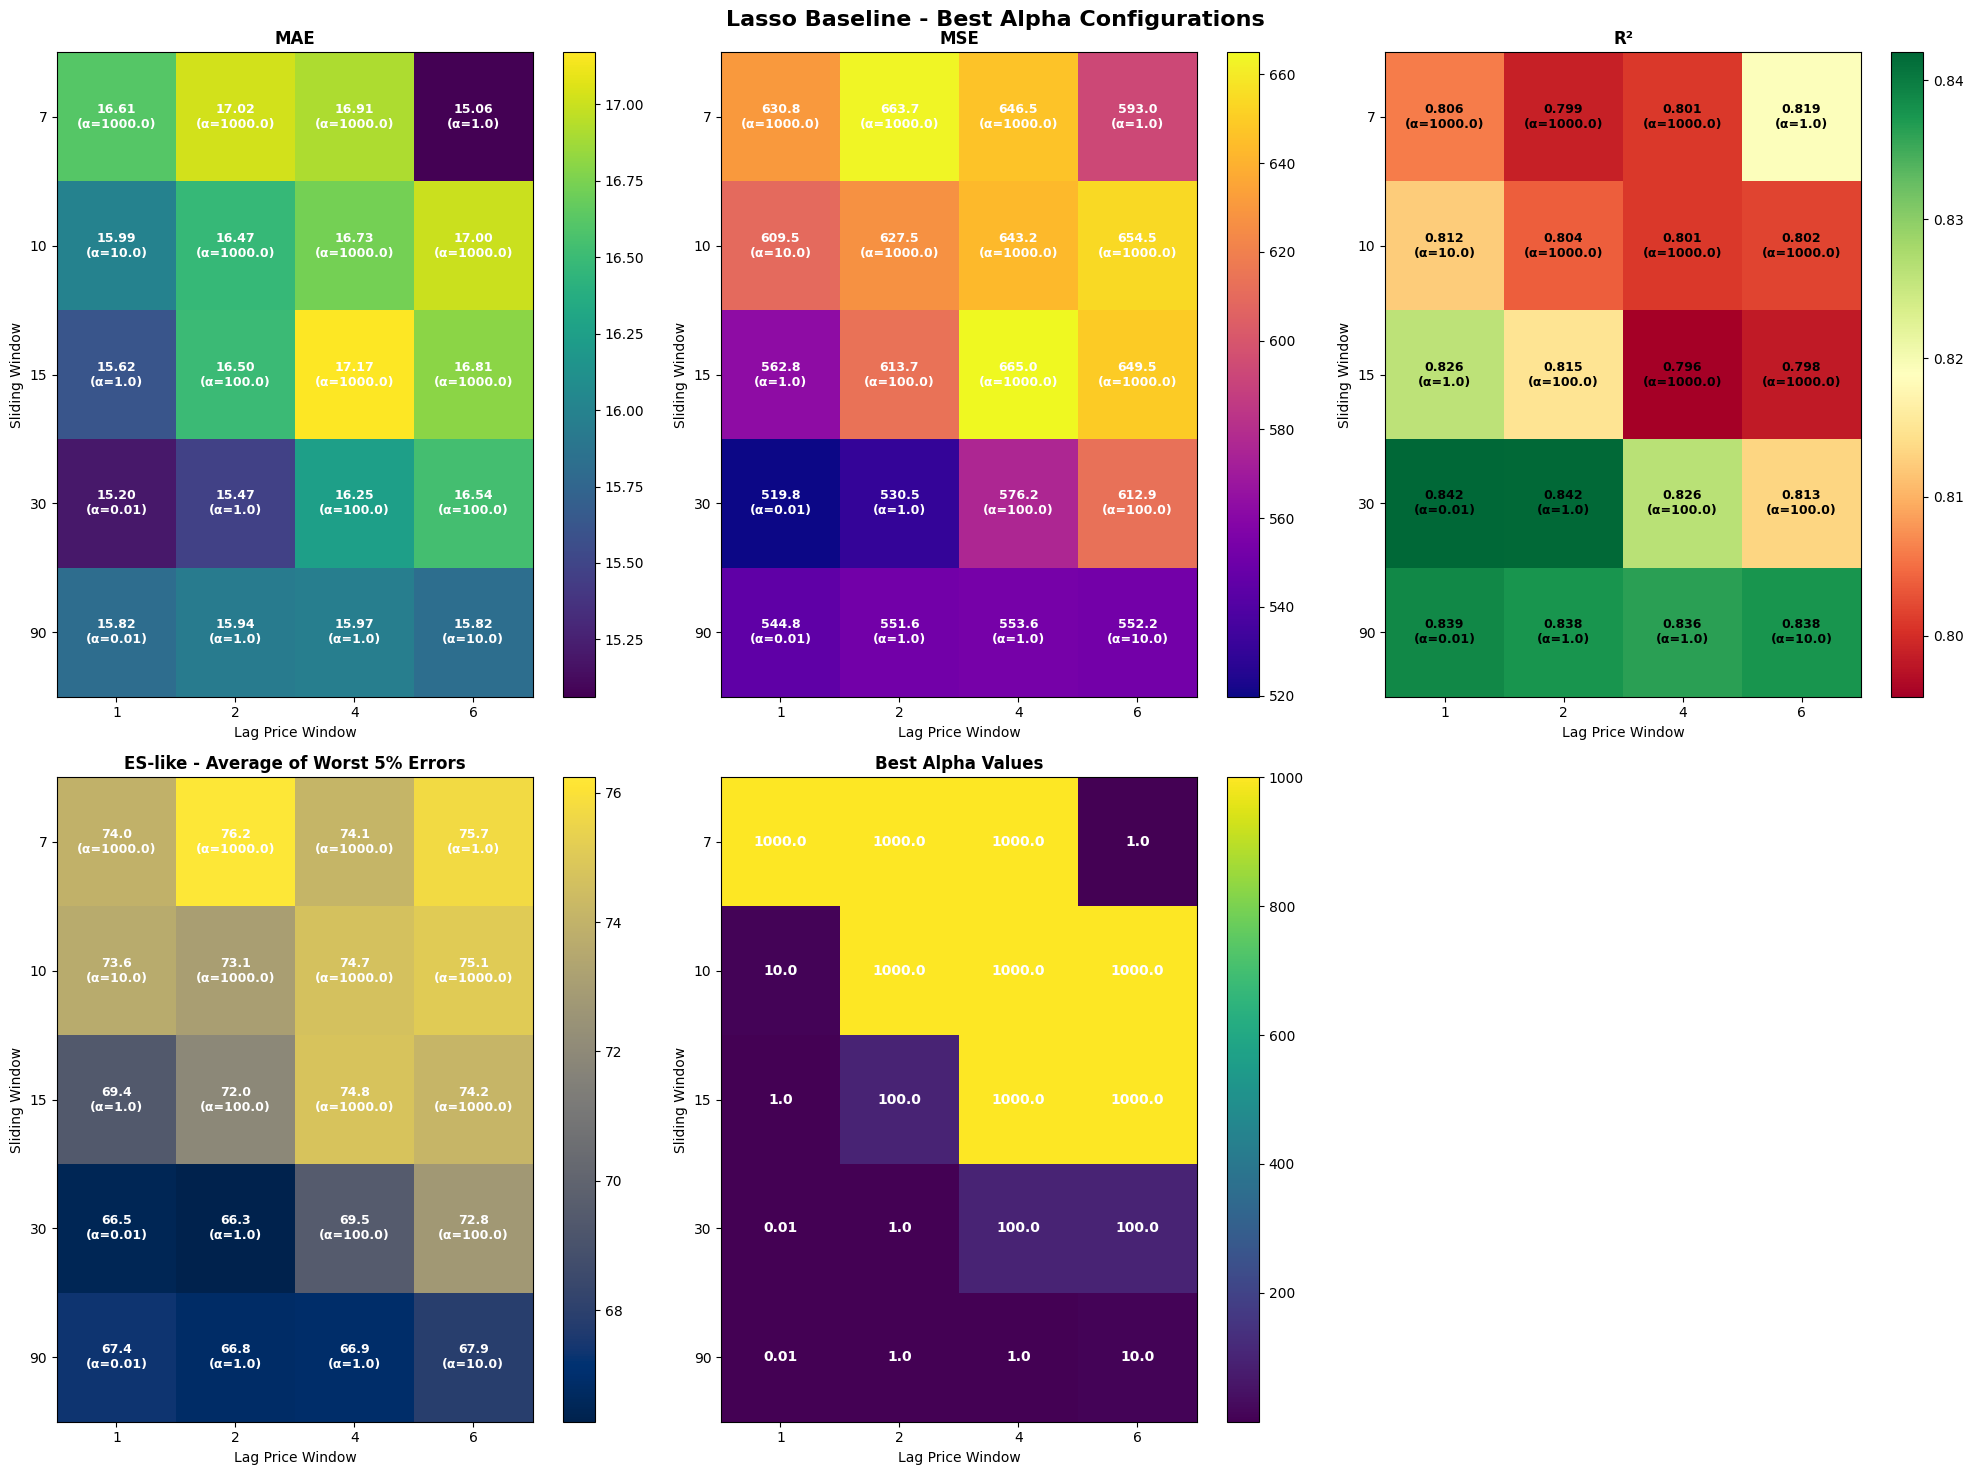

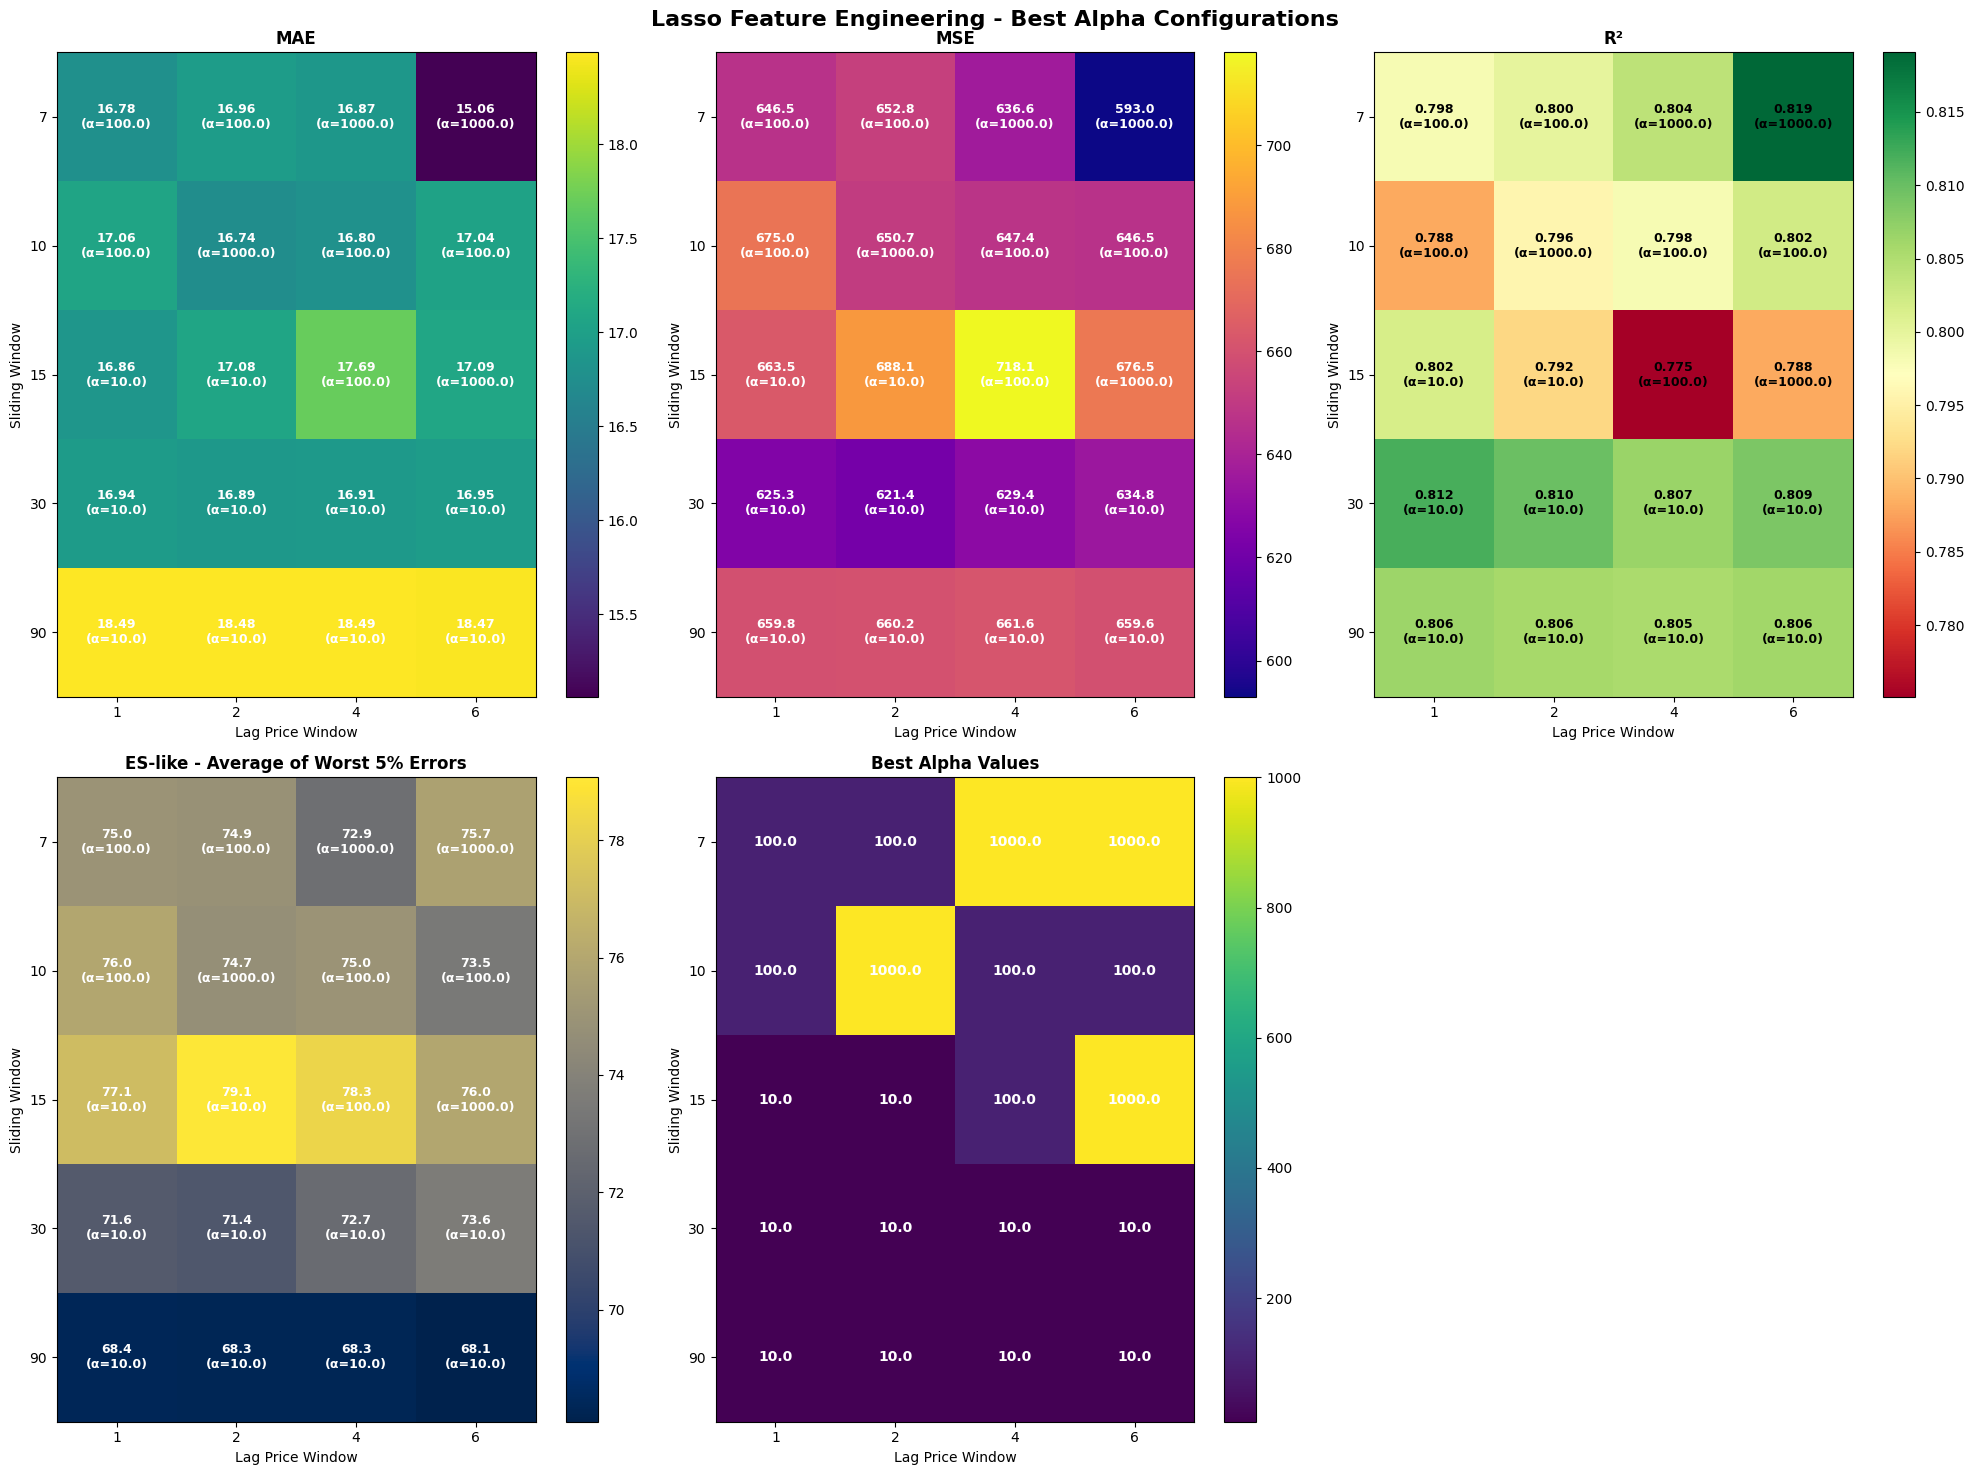

In [30]:
# Use the best alpha approach
plot_lasso_best_alpha_heatmaps(lasso_baseline_ranked, 'Lasso Baseline')
plot_lasso_best_alpha_heatmaps(lasso_fe_ranked, 'Lasso Feature Engineering')

Random Forest

In [31]:
# Recreate the complete database for random forest models
load_rf_baseline_data = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/3_randomforest/random_forest_full_baseline_results.csv', header=0)

load_rf_fe_data = pd.read_csv('/Users/rodrigodelama/Library/Mobile Documents/com~apple~CloudDocs/uc3m/TFG/code/final_metrics/3_randomforest/random_forest_full_fe_results.csv', header=0)

# rank the random forest models
random_forest_baseline_ranked = find_best_optimal_models(load_rf_baseline_data)
random_forest_fe_ranked = find_best_optimal_models(load_rf_fe_data)

# print the head of the ranked random forest dataframes
# print("\nRandom Forest Baseline Ranked:")
# print(random_forest_baseline_ranked.head())
# print("\nRandom Forest FE Ranked:")
# print(random_forest_fe_ranked.head())

In [32]:
def plot_rf_best_config_heatmaps(df, model_name, figsize=(25, 15)):
    """Plot heatmaps showing best RF configuration and corresponding metric values"""
    
    # Find best configuration for each sliding_window, lag_price_window combination
    best_configs = df.loc[df.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    # Create pivot tables for metrics with best configuration
    mae_pivot = best_configs.pivot_table(values='mae', index='sliding_window', columns='lag_price_window')
    mse_pivot = best_configs.pivot_table(values='mse', index='sliding_window', columns='lag_price_window')
    r2_pivot = best_configs.pivot_table(values='r2', index='sliding_window', columns='lag_price_window')
    worst_error_pivot = best_configs.pivot_table(values='worst_avg_error', index='sliding_window', columns='lag_price_window')
    n_estimators_pivot = best_configs.pivot_table(values='n_estimators', index='sliding_window', columns='lag_price_window')
    max_depth_pivot = best_configs.pivot_table(values='max_depth', index='sliding_window', columns='lag_price_window')
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(f'{model_name} - Best Configuration Analysis', fontsize=16, fontweight='bold')
    
    # MAE with best config
    im1 = axes[0, 0].imshow(mae_pivot.values, cmap='viridis', aspect='auto')
    axes[0, 0].set_title('MAE (Best Config)', fontweight='bold')
    axes[0, 0].set_xlabel('Lag Price Window')
    axes[0, 0].set_ylabel('Sliding Window')
    axes[0, 0].set_xticks(range(len(mae_pivot.columns)))
    axes[0, 0].set_xticklabels(mae_pivot.columns)
    axes[0, 0].set_yticks(range(len(mae_pivot.index)))
    axes[0, 0].set_yticklabels(mae_pivot.index)
    plt.colorbar(im1, ax=axes[0, 0])
    
    for i in range(len(mae_pivot.index)):
        for j in range(len(mae_pivot.columns)):
            if not np.isnan(mae_pivot.iloc[i, j]):
                mae_val = mae_pivot.iloc[i, j]
                n_est = int(n_estimators_pivot.iloc[i, j])
                depth = max_depth_pivot.iloc[i, j]
                depth_str = f'{int(depth)}' if not pd.isna(depth) and depth != 0 and str(depth).lower() != 'none' else 'None'
                axes[0, 0].text(j, i, f'{mae_val:.2f}\n({n_est},{depth_str})', 
                               ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # MSE with best config
    im2 = axes[0, 1].imshow(mse_pivot.values, cmap='plasma', aspect='auto')
    axes[0, 1].set_title('MSE (Best Config)', fontweight='bold')
    axes[0, 1].set_xlabel('Lag Price Window')
    axes[0, 1].set_ylabel('Sliding Window')
    axes[0, 1].set_xticks(range(len(mse_pivot.columns)))
    axes[0, 1].set_xticklabels(mse_pivot.columns)
    axes[0, 1].set_yticks(range(len(mse_pivot.index)))
    axes[0, 1].set_yticklabels(mse_pivot.index)
    plt.colorbar(im2, ax=axes[0, 1])
    
    for i in range(len(mse_pivot.index)):
        for j in range(len(mse_pivot.columns)):
            if not np.isnan(mse_pivot.iloc[i, j]):
                mse_val = mse_pivot.iloc[i, j]
                n_est = int(n_estimators_pivot.iloc[i, j])
                depth = max_depth_pivot.iloc[i, j]
                depth_str = f'{int(depth)}' if not pd.isna(depth) and depth != 0 and str(depth).lower() != 'none' else 'None'
                axes[0, 1].text(j, i, f'{mse_val:.1f}\n({n_est},{depth_str})', 
                               ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # R² with best config
    im3 = axes[0, 2].imshow(r2_pivot.values, cmap='RdYlGn', aspect='auto')
    axes[0, 2].set_title('R² (Best Config)', fontweight='bold')
    axes[0, 2].set_xlabel('Lag Price Window')
    axes[0, 2].set_ylabel('Sliding Window')
    axes[0, 2].set_xticks(range(len(r2_pivot.columns)))
    axes[0, 2].set_xticklabels(r2_pivot.columns)
    axes[0, 2].set_yticks(range(len(r2_pivot.index)))
    axes[0, 2].set_yticklabels(r2_pivot.index)
    plt.colorbar(im3, ax=axes[0, 2])
    
    for i in range(len(r2_pivot.index)):
        for j in range(len(r2_pivot.columns)):
            if not np.isnan(r2_pivot.iloc[i, j]):
                r2_val = r2_pivot.iloc[i, j]
                n_est = int(n_estimators_pivot.iloc[i, j])
                depth = max_depth_pivot.iloc[i, j]
                depth_str = f'{int(depth)}' if not pd.isna(depth) and depth != 0 and str(depth).lower() != 'none' else 'None'
                axes[0, 2].text(j, i, f'{r2_val:.3f}\n({n_est},{depth_str})', 
                               ha='center', va='center', color='black', fontweight='bold', fontsize=9)
    
    # Worst Error with best config
    im4 = axes[1, 0].imshow(worst_error_pivot.values, cmap='cividis', aspect='auto')
    axes[1, 0].set_title('ES-like - Average of Worst 5% Errors (Best Config)', fontweight='bold')
    axes[1, 0].set_xlabel('Lag Price Window')
    axes[1, 0].set_ylabel('Sliding Window')
    axes[1, 0].set_xticks(range(len(worst_error_pivot.columns)))
    axes[1, 0].set_xticklabels(worst_error_pivot.columns)
    axes[1, 0].set_yticks(range(len(worst_error_pivot.index)))
    axes[1, 0].set_yticklabels(worst_error_pivot.index)
    plt.colorbar(im4, ax=axes[1, 0])
    
    for i in range(len(worst_error_pivot.index)):
        for j in range(len(worst_error_pivot.columns)):
            if not np.isnan(worst_error_pivot.iloc[i, j]):
                error_val = worst_error_pivot.iloc[i, j]
                n_est = int(n_estimators_pivot.iloc[i, j])
                depth = max_depth_pivot.iloc[i, j]
                depth_str = f'{int(depth)}' if not pd.isna(depth) and depth != 0 and str(depth).lower() != 'none' else 'None'
                axes[1, 0].text(j, i, f'{error_val:.1f}\n({n_est},{depth_str})', 
                               ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    # Best n_estimators heatmap
    im5 = axes[1, 1].imshow(n_estimators_pivot.values, cmap='viridis', aspect='auto')
    axes[1, 1].set_title('Best n_estimators', fontweight='bold')
    axes[1, 1].set_xlabel('Lag Price Window')
    axes[1, 1].set_ylabel('Sliding Window')
    axes[1, 1].set_xticks(range(len(n_estimators_pivot.columns)))
    axes[1, 1].set_xticklabels(n_estimators_pivot.columns)
    axes[1, 1].set_yticks(range(len(n_estimators_pivot.index)))
    axes[1, 1].set_yticklabels(n_estimators_pivot.index)
    plt.colorbar(im5, ax=axes[1, 1])
    
    for i in range(len(n_estimators_pivot.index)):
        for j in range(len(n_estimators_pivot.columns)):
            if not np.isnan(n_estimators_pivot.iloc[i, j]):
                axes[1, 1].text(j, i, f'{int(n_estimators_pivot.iloc[i, j])}', 
                               ha='center', va='center', color='white', fontweight='bold')
    
    # Best max_depth heatmap
    im6 = axes[1, 2].imshow(max_depth_pivot.values, cmap='plasma', aspect='auto')
    axes[1, 2].set_title('Best max_depth', fontweight='bold')
    axes[1, 2].set_xlabel('Lag Price Window')
    axes[1, 2].set_ylabel('Sliding Window')
    axes[1, 2].set_xticks(range(len(max_depth_pivot.columns)))
    axes[1, 2].set_xticklabels(max_depth_pivot.columns)
    axes[1, 2].set_yticks(range(len(max_depth_pivot.index)))
    axes[1, 2].set_yticklabels(max_depth_pivot.index)
    plt.colorbar(im6, ax=axes[1, 2])
    
    for i in range(len(max_depth_pivot.index)):
        for j in range(len(max_depth_pivot.columns)):
            if not np.isnan(max_depth_pivot.iloc[i, j]):
                depth_val = max_depth_pivot.iloc[i, j]
                # Handle different representations of None/unlimited depth
                if pd.isna(depth_val) or depth_val == 0 or str(depth_val).lower() == 'none':
                    display_val = 'None'
                else:
                    display_val = f'{int(depth_val)}'
                axes[1, 2].text(j, i, display_val, 
                               ha='center', va='center', color='white', fontweight='bold')
            else:
                # If the pivot value itself is NaN, still show 'None'
                axes[1, 2].text(j, i, 'None', 
                               ha='center', va='center', color='black', fontweight='bold')
    
    plt.tight_layout()
    # save the figure
    plt.savefig(f'{model_name}_best_config_heatmaps.png', dpi=300, bbox_inches='tight')
    plt.show()

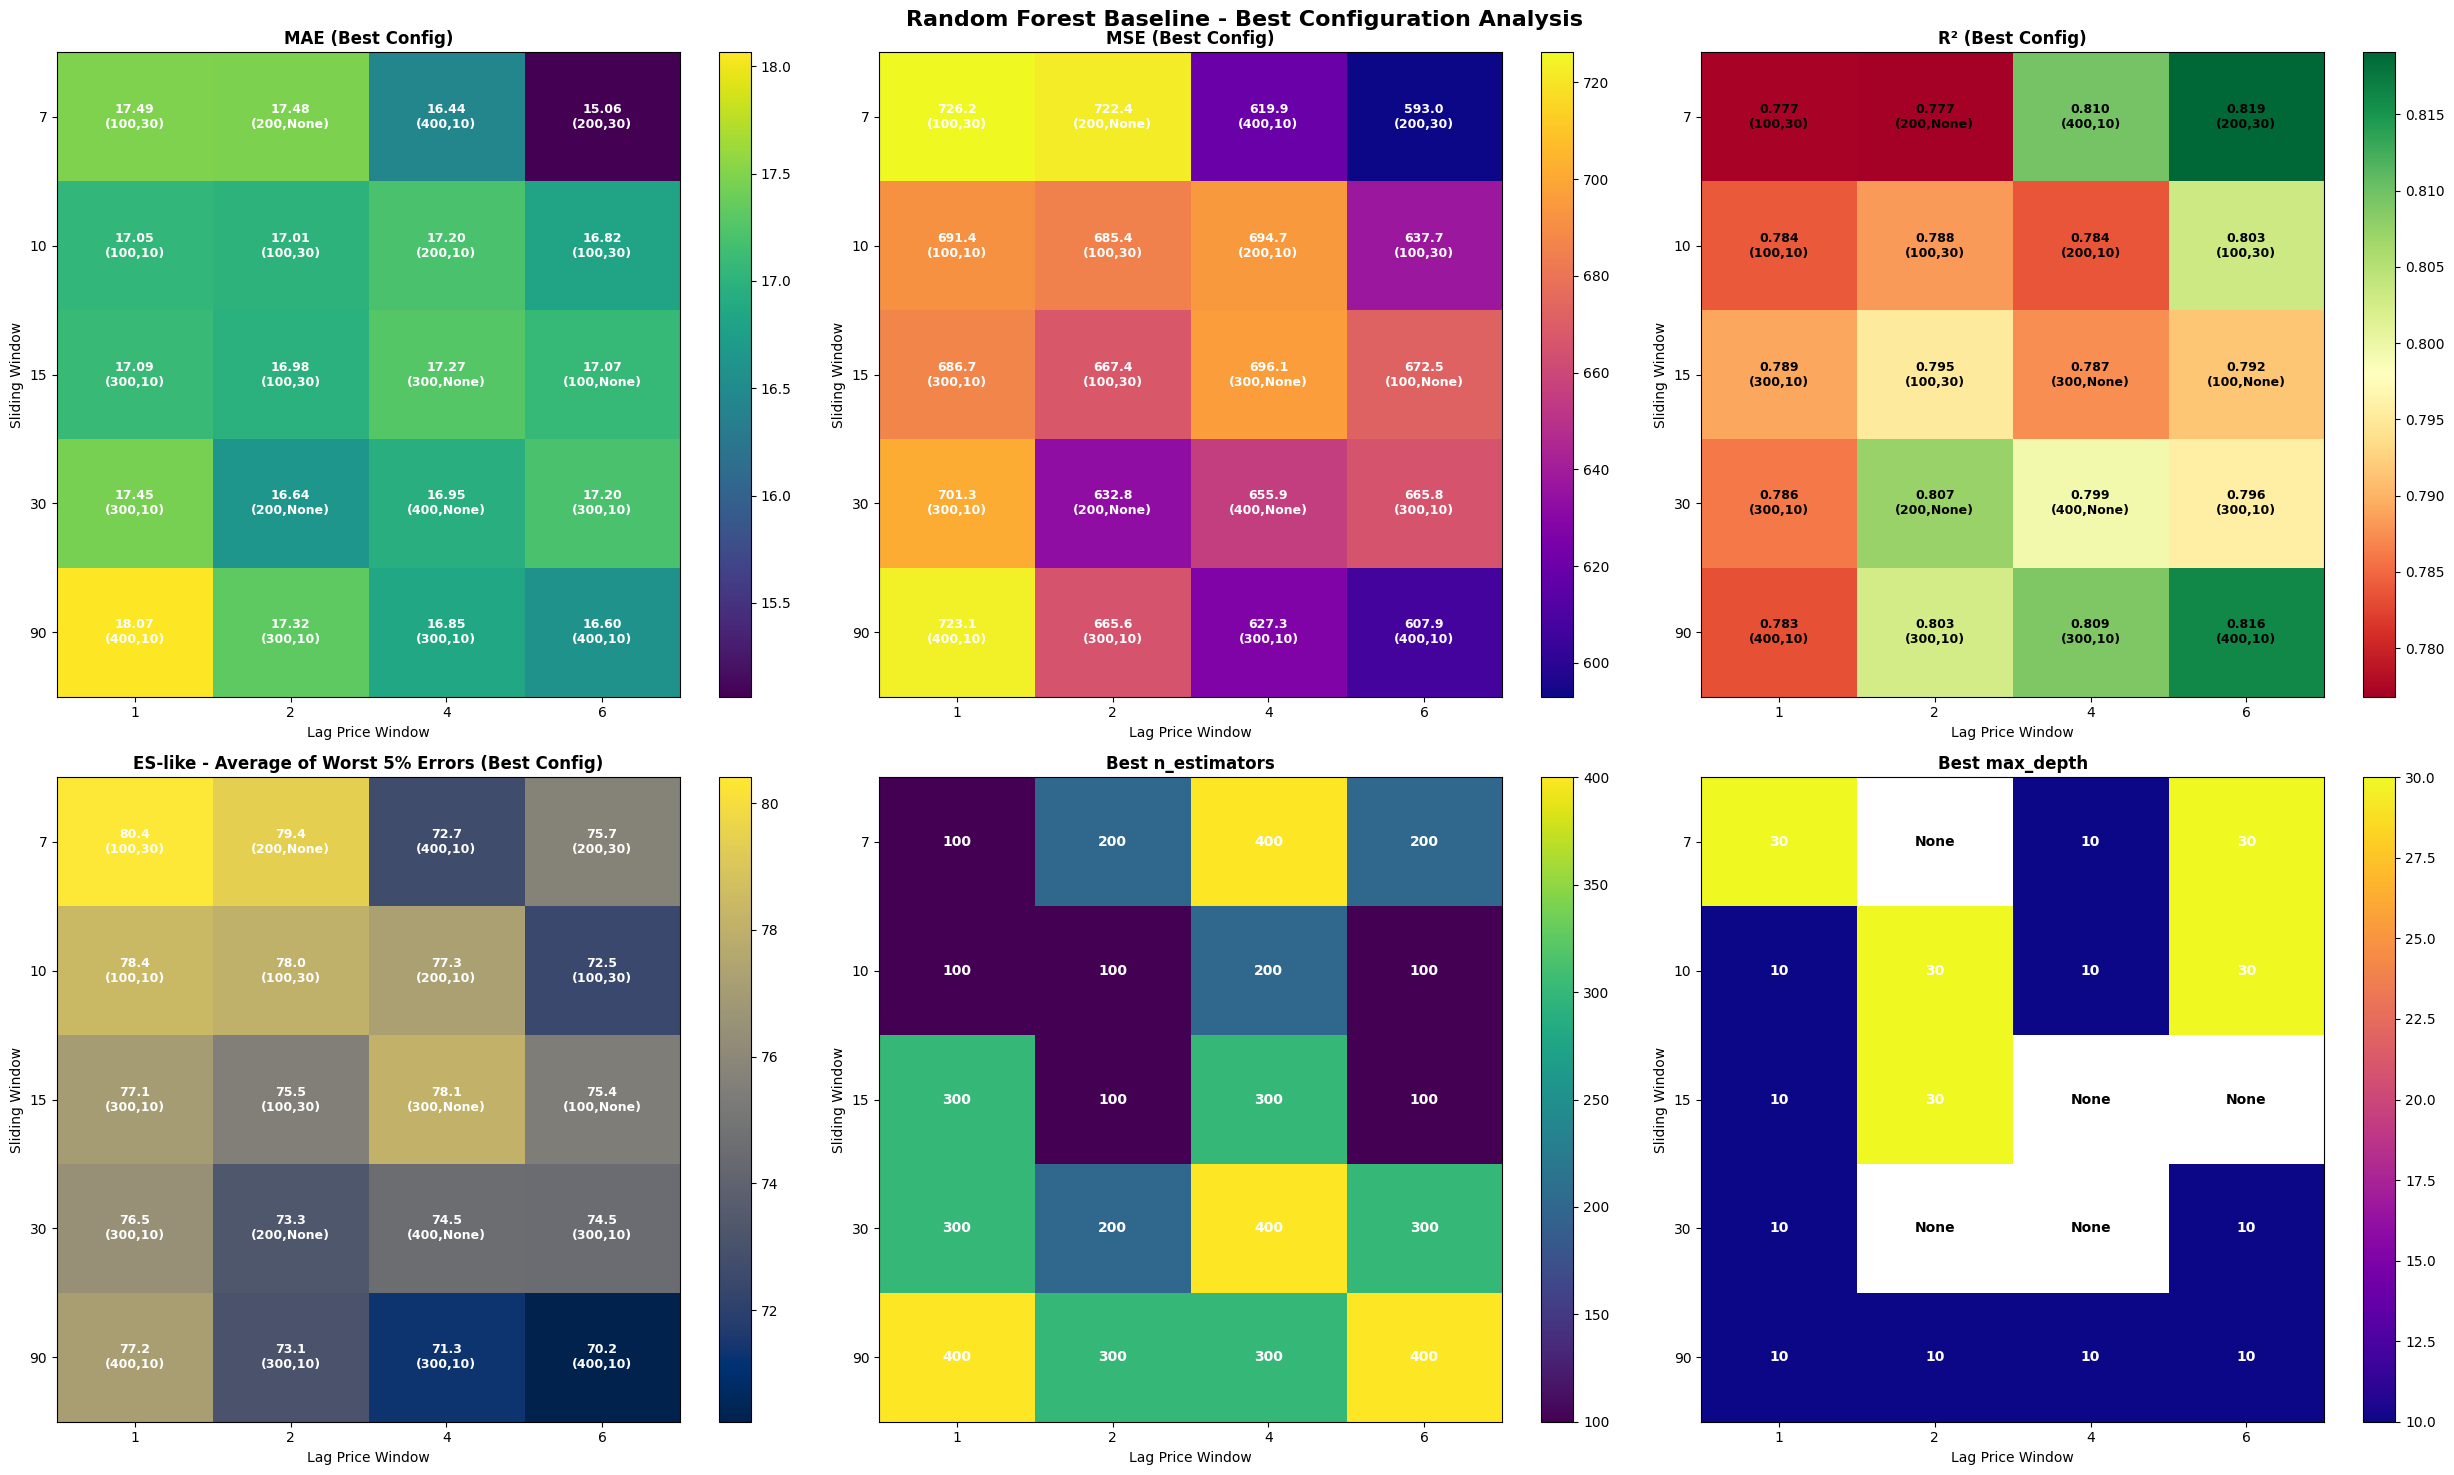

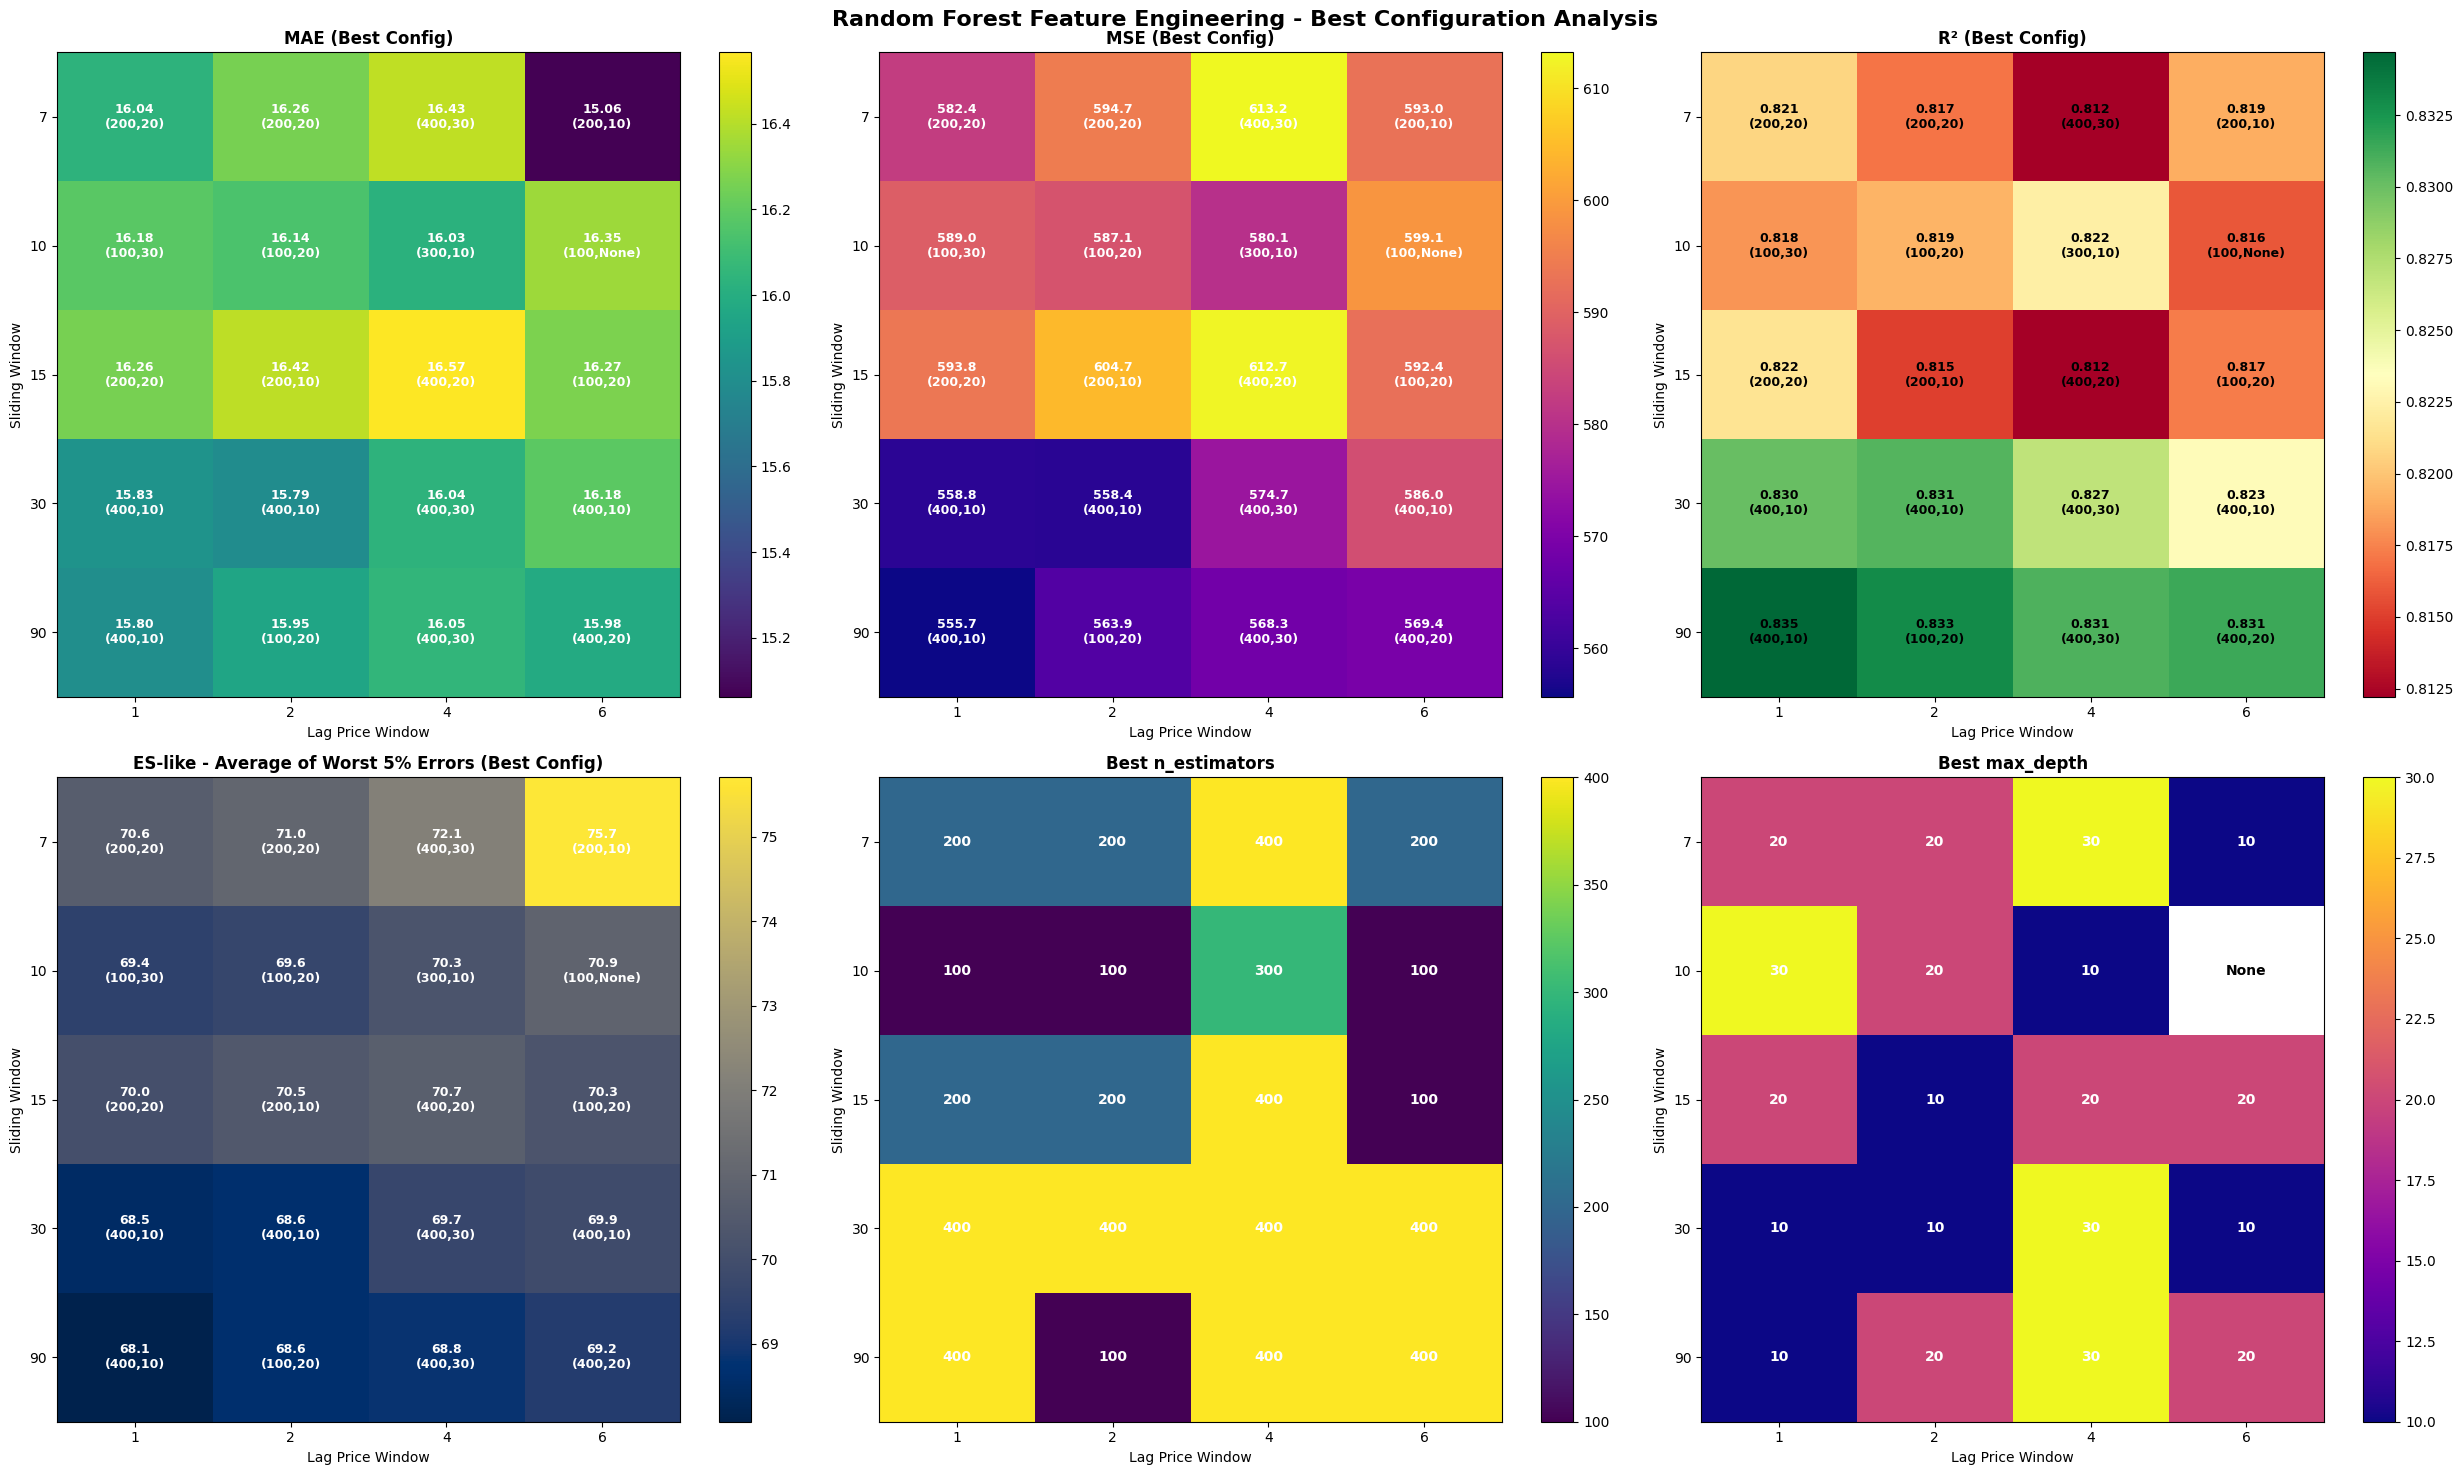

In [33]:
# Comprehensive Random Forest analysis
plot_rf_best_config_heatmaps(random_forest_baseline_ranked, 'Random Forest Baseline')
plot_rf_best_config_heatmaps(random_forest_fe_ranked, 'Random Forest Feature Engineering')

In [44]:
# Additional function for hyperparameter distribution analysis
def plot_rf_hyperparameter_analysis(df, model_name, figsize=(20, 6)):
    """Plot detailed hyperparameter distribution and interaction analysis"""
    
    best_configs = df.loc[df.groupby(['sliding_window', 'lag_price_window'])['avg_rank'].idxmin()]
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(f'{model_name} - Hyperparameter Analysis', fontsize=16, fontweight='bold')
    
    # Distribution of best n_estimators
    axes[0].hist(best_configs['n_estimators'], bins=len(best_configs['n_estimators'].unique()), 
                alpha=0.7, color='skyblue', edgecolor='black')
    axes[0].set_title('Distribution of Best n_estimators', fontweight='bold')
    axes[0].set_xlabel('n_estimators')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)
    
    # Distribution of best max_depth
    # Handle None values properly - replace NaN/None with a string 'None' for counting
    max_depth_clean = best_configs['max_depth'].fillna('None')
    max_depth_clean = max_depth_clean.replace([0, '0'], 'None')  # Also treat 0 as None
    max_depth_counts = max_depth_clean.value_counts()  # Remove sort_index() to avoid TypeError
    
    axes[1].bar(range(len(max_depth_counts)), max_depth_counts.values, 
               alpha=0.7, color='lightgreen', edgecolor='black')
    axes[1].set_title('Distribution of Best max_depth', fontweight='bold')
    axes[1].set_xlabel('max_depth')
    axes[1].set_ylabel('Frequency')
    axes[1].set_xticks(range(len(max_depth_counts)))
    # Create proper labels for the x-axis
    labels = []
    for x in max_depth_counts.index:
        if str(x).lower() == 'none' or pd.isna(x) or x == 0:
            labels.append('None')
        else:
            labels.append(f'{int(float(x))}')
    axes[1].set_xticklabels(labels)
    axes[1].grid(True, alpha=0.3)
    
    # Hyperparameter combination heatmap
    # Create a clean version for grouping
    best_configs_clean = best_configs.copy()
    best_configs_clean['max_depth_clean'] = best_configs_clean['max_depth'].fillna('None')
    best_configs_clean['max_depth_clean'] = best_configs_clean['max_depth_clean'].replace([0, '0'], 'None')
    
    combo_counts = best_configs_clean.groupby(['n_estimators', 'max_depth_clean']).size().unstack(fill_value=0)
    im = axes[2].imshow(combo_counts.values, cmap='Blues', aspect='auto')
    axes[2].set_title('Best Hyperparameter Combinations', fontweight='bold')
    axes[2].set_xlabel('max_depth')
    axes[2].set_ylabel('n_estimators')
    axes[2].set_xticks(range(len(combo_counts.columns)))
    # Create proper labels for max_depth
    x_labels = []
    for x in combo_counts.columns:
        if str(x).lower() == 'none' or pd.isna(x) or x == 0:
            x_labels.append('None')
        else:
            x_labels.append(f'{int(float(x))}')
    axes[2].set_xticklabels(x_labels)
    axes[2].set_yticks(range(len(combo_counts.index)))
    axes[2].set_yticklabels(combo_counts.index)
    axes[2].invert_yaxis()  # Reverse y-axis to make it ascending
    plt.colorbar(im, ax=axes[2])
    
    plt.tight_layout()
    plt.savefig(f'{model_name}_hyperparameter_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


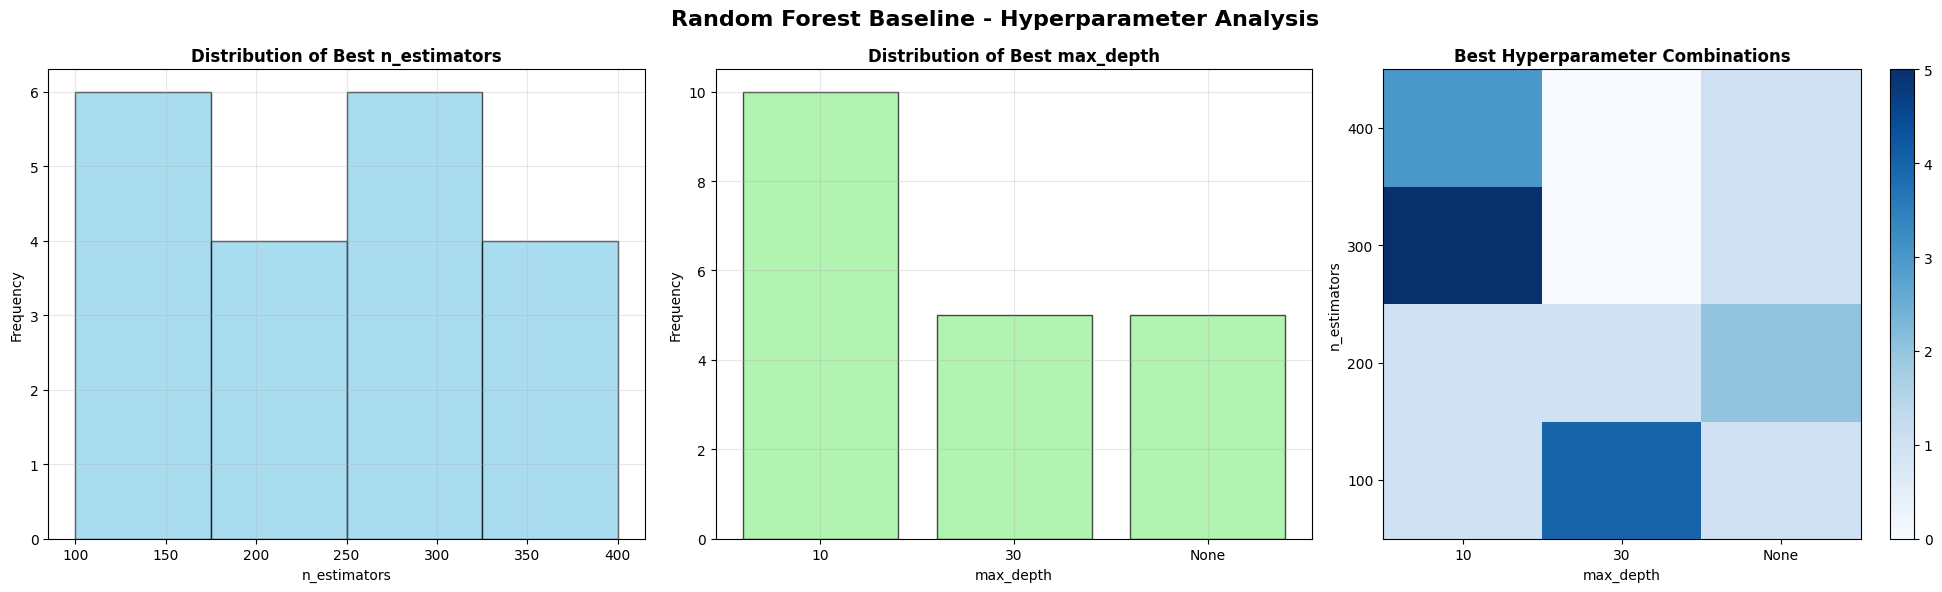

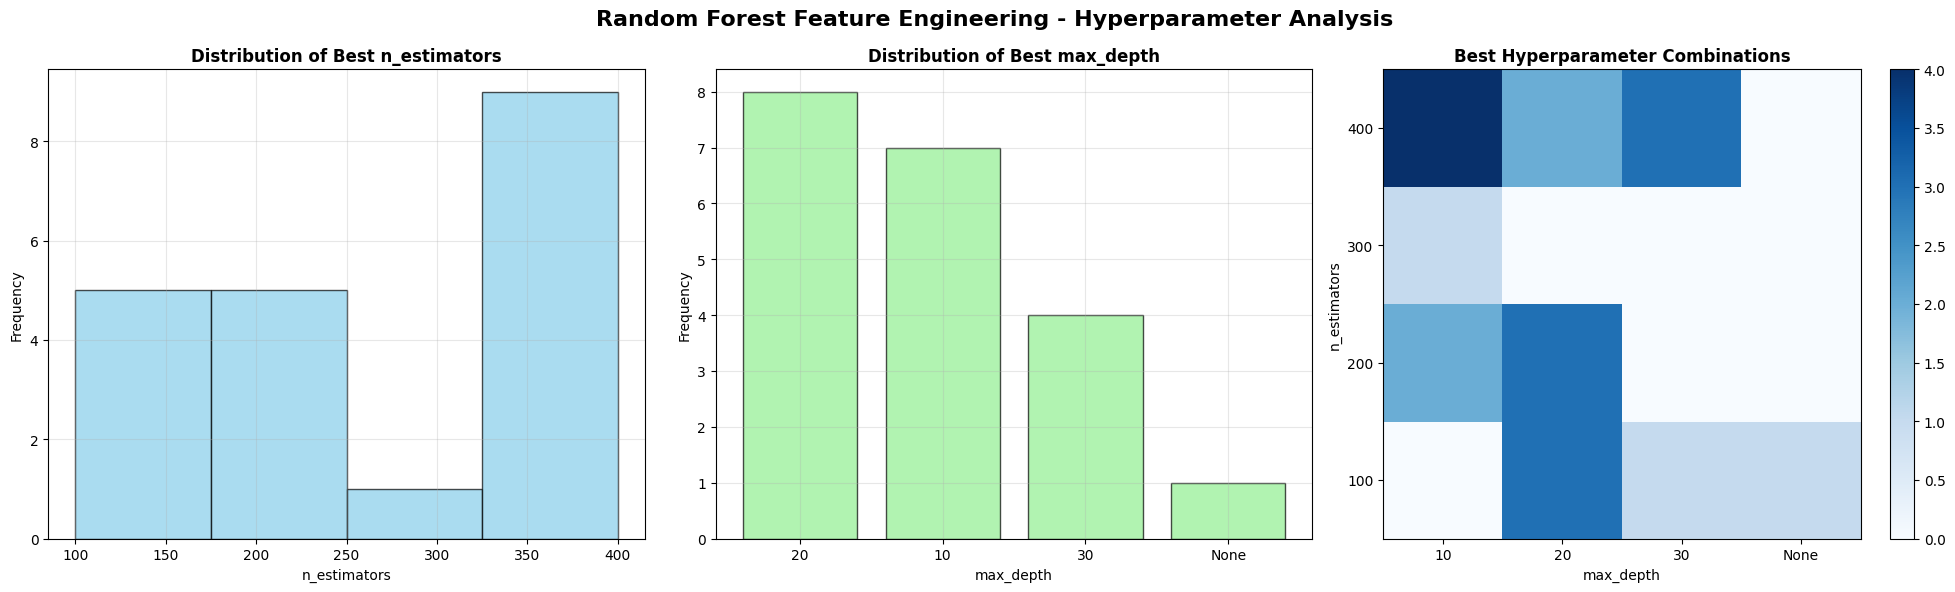

In [45]:
# Additional hyperparameter analysis
plot_rf_hyperparameter_analysis(random_forest_baseline_ranked, 'Random Forest Baseline')
plot_rf_hyperparameter_analysis(random_forest_fe_ranked, 'Random Forest Feature Engineering')